# Variational Autoencoder (VAE) for Data Generation and Validation
This notebook demonstrates how to use PyTorch to build and train a VAE for data generation and validation.

**Outline:**
1. Import required libraries (PyTorch, NumPy, etc.)
2. Load and preprocess a dataset (images or numeric data)
3. Define the VAE architecture
4. Train the VAE
5. Generate new samples from the latent space
6. Validate generated data (visualization, statistics)

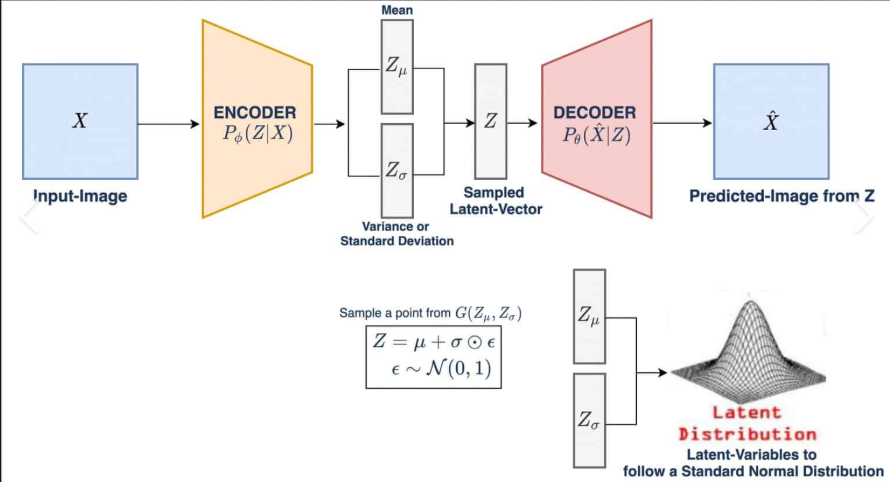

In [1]:
# Imports and MNIST data loading
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [2]:
# VAE model definition (2D latent space)
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28*28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [3]:
# Instantiate VAE, optimizer, and loss function
torch.manual_seed(0)
vae = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='sum')
    # KL divergence
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

In [4]:
# Train the VAE (few epochs for demo)
epochs = 10
vae.train()
for epoch in range(1, epochs+1):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/10 - Loss: 50.5435
Epoch 2/10 - Loss: 42.1235
Epoch 2/10 - Loss: 42.1235
Epoch 3/10 - Loss: 40.4167
Epoch 3/10 - Loss: 40.4167
Epoch 4/10 - Loss: 39.3608
Epoch 4/10 - Loss: 39.3608
Epoch 5/10 - Loss: 38.4910
Epoch 5/10 - Loss: 38.4910
Epoch 6/10 - Loss: 37.8054
Epoch 6/10 - Loss: 37.8054
Epoch 7/10 - Loss: 37.3262
Epoch 7/10 - Loss: 37.3262
Epoch 8/10 - Loss: 36.9482
Epoch 8/10 - Loss: 36.9482
Epoch 9/10 - Loss: 36.6423
Epoch 9/10 - Loss: 36.6423
Epoch 10/10 - Loss: 36.4132
Epoch 10/10 - Loss: 36.4132


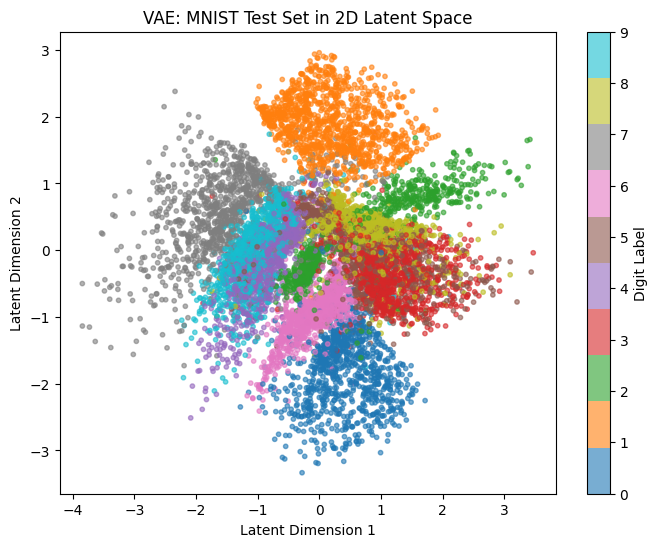

In [5]:
# Visualize the 2D latent space for test set
vae.eval()
latents = []
labels = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, logvar = vae.encode(x)
        z = mu  # Use mean for visualization
        latents.append(z.cpu().numpy())
        labels.append(y.numpy())
latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

plt.figure(figsize=(8,6))
scatter = plt.scatter(latents[:,0], latents[:,1], c=labels, cmap='tab10', alpha=0.6, s=10)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Label')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('VAE: MNIST Test Set in 2D Latent Space')
plt.show()

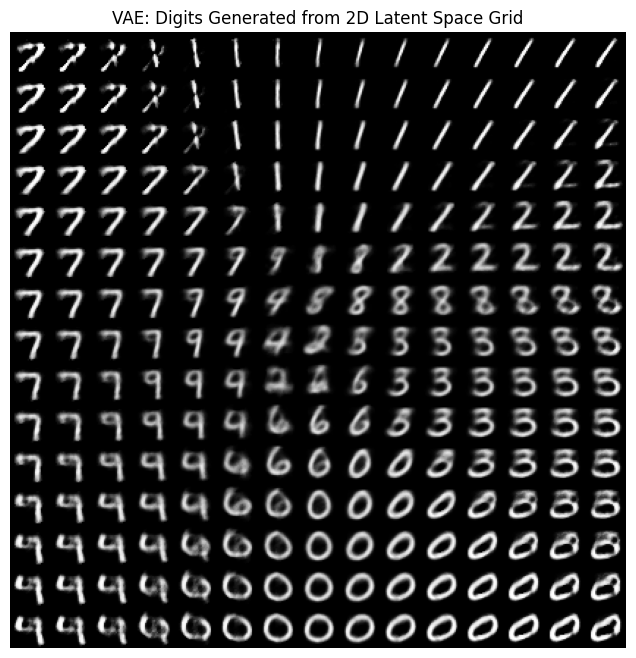

In [6]:
# Generate new digits by sampling from the 2D latent space grid
n = 15  # grid size
range_lim = 3
z1 = np.linspace(-range_lim, range_lim, n)
z2 = np.linspace(-range_lim, range_lim, n)
canvas = np.zeros((28 * n, 28 * n))
vae.eval()
with torch.no_grad():
    for i, xi in enumerate(z1):
        for j, yi in enumerate(z2):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_gen = vae.decode(z).cpu().numpy().reshape(28, 28)
            canvas[(n-1-j)*28:(n-1-j+1)*28, i*28:(i+1)*28] = x_gen
plt.figure(figsize=(8,8))
plt.imshow(canvas, cmap='gray')
plt.axis('off')
plt.title('VAE: Digits Generated from 2D Latent Space Grid')
plt.show()

### Business Relevance of VAEs

Variational Autoencoders (VAEs) are powerful generative models with real-world business applications:

- **Synthetic Data Generation:**
  - VAEs can generate realistic synthetic data (images, text, tabular) for augmenting small datasets, privacy-preserving analytics, or testing systems when real data is scarce or sensitive.

- **Anomaly Detection:**
  - By learning the "normal" data distribution, VAEs can flag outliers or anomalies (e.g., fraud detection, defect detection in manufacturing, medical imaging).

- **Data Compression:**
  - VAEs learn compact, meaningful representations (latent codes) that can be used for efficient storage, transmission, or downstream tasks.

- **Data Imputation and Denoising:**
  - VAEs can fill in missing values or remove noise from data, improving data quality for analytics and machine learning.

- **Creative Applications:**
  - VAEs enable controllable generation and interpolation in design, art, music, and content creation (e.g., generating new product designs, faces, or handwriting styles).

- **Representation Learning:**
  - The learned latent space can be used for clustering, visualization, or as features for other ML models.

**Summary:**
- VAEs are not just academic—they address real business needs in data augmentation, anomaly detection, privacy, creativity, and more, making them valuable tools in modern AI-driven organizations.

### Are VAEs Used in Modern GenAI Models Like DALL-E?

- **VAEs are foundational generative models** and have influenced the development of many modern GenAI systems.
- However, state-of-the-art models like **DALL-E, Imagen, and Stable Diffusion** primarily use more advanced architectures:
  - **Diffusion models** (e.g., Stable Diffusion, Imagen) generate images by iteratively denoising random noise, achieving high fidelity and diversity.
  - **Autoregressive transformers** (e.g., DALL-E, GPT) generate data one step at a time, modeling complex dependencies.
- **VAEs are still used** in some modern systems, often as components:
  - As building blocks for hierarchical or hybrid models.
  - For learning compressed representations or as priors in diffusion models.
  - In research and production for tasks where fast, controllable, or interpretable generation is needed.

**Summary:**
- VAEs are not the main engine behind today's most powerful GenAI models, but their ideas and components are still relevant and sometimes integrated into larger, more complex architectures.